# Portfolio Exam

Cosima Baumeier

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import balanced_accuracy_score, recall_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer

## Task 1 - Context

#### Scenario
I am a Data Scientist working for a larger hospital. I have been given the opportunity to collaborate with the Obstetrics and Gynecology department. In current practice, doctors and nursing staff heavily rely on the manual and visual interpretation of Cardiotocography (CTG) data during pregnancy and during labor. Although experienced personnel perform excellent work, the interpretation is complex, time-consuming and can be prone to human fatigue or subtle errors, especially during multiple simultaneous monitoring sessions. This can lead to delayed interventions or unnecessary procedures.

I propose a project to develop a machine learning model that analyzes real-time CTG data and classifies the fetal health status into three categories: Normal, Suspect and Pathological. This model would serve as an intelligent support system for medical professionals, aiming to objectify CTG interpretation, accelerate the detection of critical conditions and improve decision-making.

#### Value
**Improved patient safety and outcomes**
- Earlier detection of complications -> earlier intervention 
- Reduction of harm: more precise and timely detection can significantly reduce the risk of fetal harm or maternal complications
- Increased birthing satisfaction: safer births contribute to more satisfied patients and their families

**Efficiency and resource prioritization**
- Optimized staff utilization: my model helps medical staff to focus their attention and resources more effectively on cases that truly require vigilant monitoring or intervention -> less time spent on manual interpretation of unremarkable CTGs means more time for critical patients
- Reduction of unnecessary interventions: a more precise assessment can help decrease unnecessary medical interventions that might be based on uncertain or over-interpreted CTG findings. This saves costs (personnel, operating rooms, postnatal care) and minimizes risks for both mother and child
- Training and standardization: my model can also serve as training tool for less experienced staff, helping to objectify and standardize interpretation across the hospital

#### Quality Criteria for model evaluation
Given that this is a medical classification problem where the costs of misclassifications (especially false negatives) are very high, two crucial quality criteria that I will use are:
- **Balanced Accuracy** because class imbalance is highly probable. There will be far more "normal" cases than "suspect" or "pathological" ones. Standard accuracy would be misleading in this case. Balanced Accuracy ensures that my model performs well across all classes, especially the minority classes (suspect, pathological), which is vital in a medical context to reliably identify rare but critical conditions.
- **Recall** for all classes, with emphasis on the recall for "pathological" and "suspect". Because, in a medical context, avoiding false negatives (e.g. falsely classifying a pathological fetus as healthy) is very important. A false negative can have severe and irreversible consequences for the child. A high recall for the "pathological" class means that my model misses few of these critical cases, directly serving patient safety. The consequences of a false positive (e.g. closer monitoring, additional tests, concern of parents) are less severe than those of an overlooked patholocical condition.

When optimizing my model, the recall for the pathological class will be the 'main' metric to improve.

## Task 2 - The Data

For this project, I used the "Fetal Health Classification" dataset from Kaggle, available at https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification

Citation: Ayres-de-Campos, D., Bernardes, J., Garrido, A., Marques-de-Sá, J. and Pereira-Leite, L. (2000), Sisporto 2.0: A program for automated analysis of cardiotocograms. J. Matern. Fetal Med., 9: 311-318. https://doi.org/10.1002/1520-6661(200009/10)9:5<311::AID-MFM12>3.0.CO;2-9

First, I will load the raw data and inspect the shape:

In [3]:
raw_data = pd.read_csv('fetal_health.csv')
raw_data.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
raw_data.shape

(2126, 22)

The dataset contains 22 columns and 2126 rows. Each row represents a Cardiotocogram (CTG) examination with 21 numerical features derived from these examinations and one target variable indicating the fetal health status. 
The features quantify various aspects of fetal heart rate (FHR) patterns and uterine contraction.

In [5]:
print("Names of the columns:")
print(raw_data.columns.tolist())

Names of the columns:
['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'histogram_tendency', 'fetal_health']


Below, you can find a breakdown of the features and the target variable:

|Variable name|Description|
|---|---|
|baseline value|Fetal Heart Rate (FHR) baseline in beats per minute. This is the mean FHR during a 10-minute segment, excluding accelerations and decelerations and periods of marked variability. It represents the fetal heart's average resting rate.| 
|accelerations|Number of accelerations per second. Accelerations are increases in FHR above the baseline.| 
|fetal_movements|Number of fetal movements per second.| 
|uterine_contractions|Number of uterine contractions (tightening of the uterus) per second.| 
|light_decelerations|Number of light decelerations per second. Decelerations are decreases in FHR from the baseline.| 
|severe_decelerations|Number of severe decelerations per second.| 
|prolonged_decelerations|Number of prolonged decelerations per second.| 
|abnormal_short_term_variability|Percentage of time with abnormal short-term variability. Short-term variability refers to the beat-to-beat changes in FHR.| 
|mean_value_of_short_term_variability|Mean value of short-term variability -> average beat-to-beat fluctuation in FHR.| 
|variance_of_short_term_variability|Variance of short-term variability.| 
|abnormal_long_term_variability|Percentage of time with abnormal long-term variability. Long-term variability refers to fluctuations in FHR over longer periods (e.g., oscillations over minutes).| 
|mean_value_of_long_term_variability|Mean value of long-term variability.| |variance_of_long_term_variability|Variance of long-term variability.| 
|histogram_width|Width of the FHR histogram. The histogram displays the distribution of FHR values over the recording period.| 
|histogram_min|Minimum FHR value in the histogram -> the lowest heart rate recorded during the CTG trace.| 
|histogram_max|Maximum FHR value in the histogram -> the highest heart rate recorded during the CTG trace.| 
|histogram_number_of_peaks|Number of peaks in the FHR histogram.| 
|histogram_number_of_zeroes|Number of zeroes in the FHR histogram.| 
|histogram_mode|Mode (most frequent value) of the FHR histogram.| 
|histogram_mean|Mean value of the FHR histogram.| 
|histogram_median|Median value of the FHR histogram.| 
|histogram_variance|Variance of the FHR histogram.| 
|fetal_health|Target Variable: Classification of fetal health status. This is the outcome variable to be predicted. It typically has three classes: 1 (Normal), 2 (Suspect), 3 (Pathological).|
|histogram_variance|Variance of the FHR histogram.|
|fetal_health|**Target Variable:** Classification of fetal health status. This is the outcome variable to be predicted. It has three classes: 1 (Normal), 2 (Suspect), 3 (Pathological).|

The dataset is suitabke for the project outlined in task 1 because:
- it directly addressed the core problem: classifying fetal health status based on objective CTG measurements -> aligns with the goal of developing a machine learning model to assist medical professionals in interpreting complex signals
- the target variable fetal_health is categorical (normal, suspect, pathological) making it a multi-class classification problem
- the data is real CTG-derived data from a medical context
- with 2126 instances, the dataset is large enough to allow for robust training and evaluation procedures

## Task 3 - IDA

Printing information about the dataset:

In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

All features and the target variable are stored as float numbers. There are no missing values.

Below, you can find a table of all the features with their mean, standard deviation, minimum, maximum and percentiles. 

In [7]:
raw_data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


Now, I am checking the class distribution of the target variable:

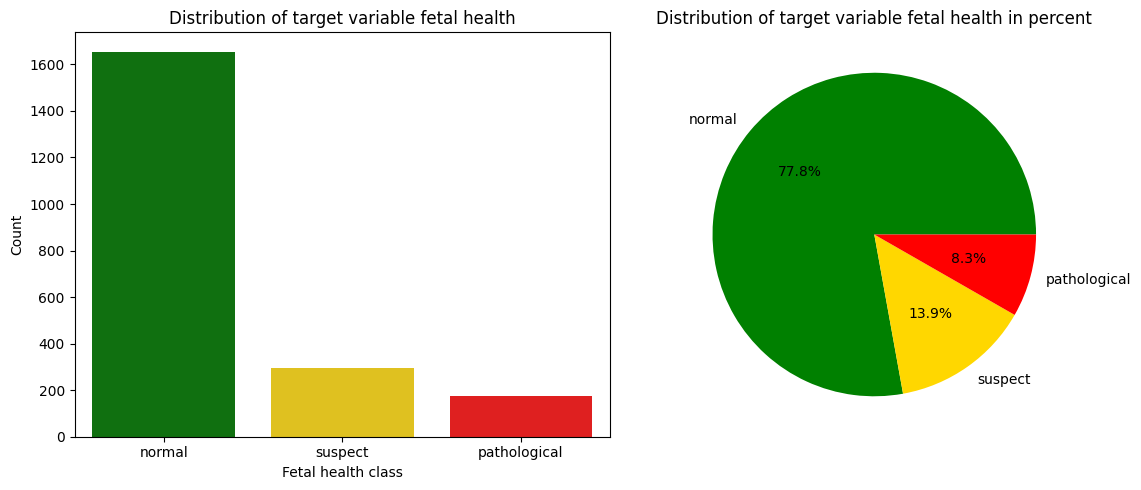

In [8]:
color_palette = ['green', 'gold', 'red'] #creating a list of the colors
class_labels = ['normal', 'suspect', 'pathological'] #creating a list of the labels

class_counts = raw_data['fetal_health'].value_counts().sort_index() #counting rows per class
class_percentages = class_counts / class_counts.sum() * 100 #calculating the percentage

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) #creating the figure for both plots

#creating the bar plot:
sns.countplot(x='fetal_health', hue='fetal_health', data=raw_data, ax=axes[0], palette=color_palette)
axes[0].set_title("Distribution of target variable fetal health")
axes[0].set_xlabel("Fetal health class")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(class_labels)
axes[0].legend_.remove()

#creating the pie plot:
axes[1].pie(class_percentages, labels=class_labels, autopct='%1.1f%%', colors=color_palette)
axes[1].set_title("Distribution of target variable fetal health in percent")

plt.tight_layout()
plt.show()


As expected, the class distributing is very imbalanced with the most common class for the fetal health being 'normal' (77.8%). 13.9% are classified as "suspect" and 8.3% as "pathological".

## Task 4 - EDA and Preprocessing

To get an impression about the features (and the target), I plotted the correlations between the variables:

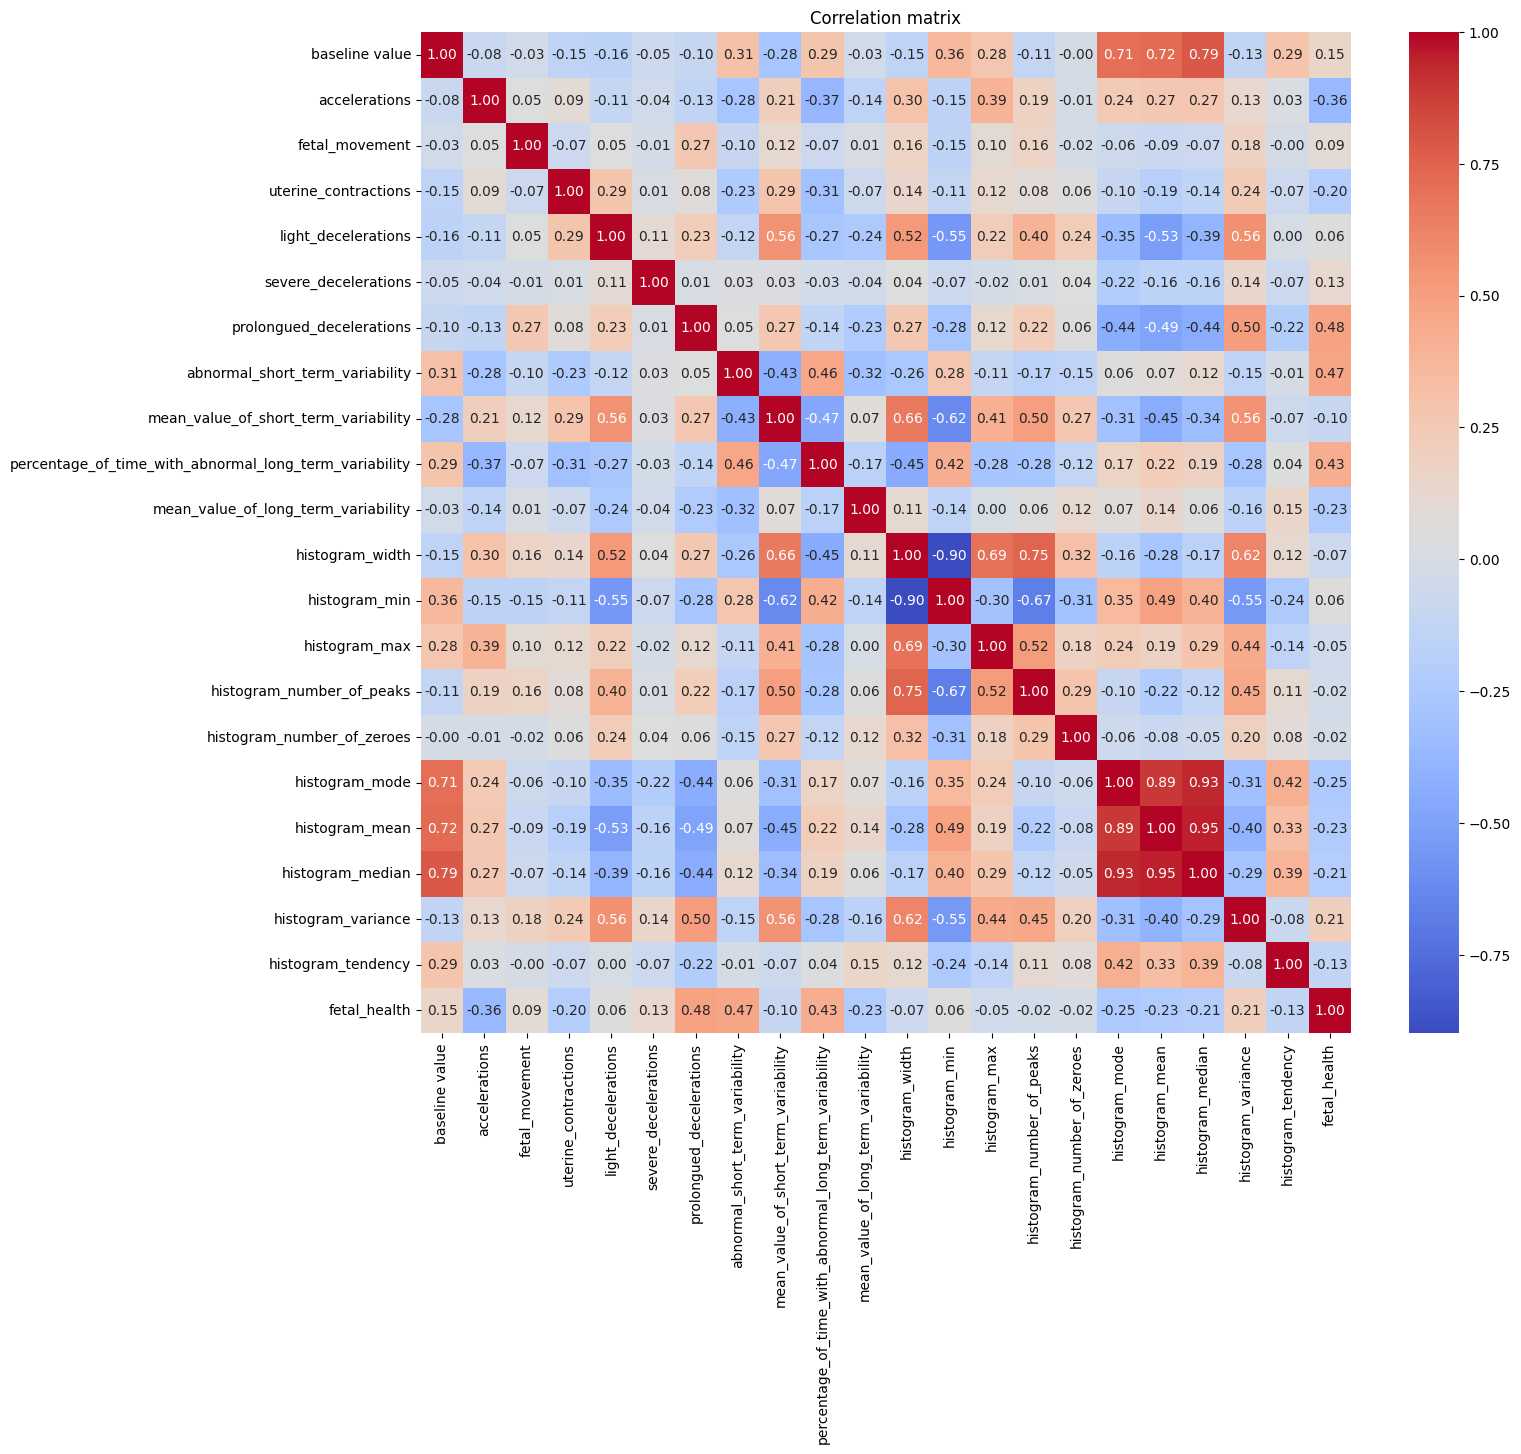

In [9]:
plt.figure(figsize=(15,13)) #creating the figure
corr = raw_data.corr() #calculating the correlations between the variables
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f') #creating a heatmat with the correlation values
plt.title("Correlation matrix")
plt.show()

The heatmap visualizes the pairwise correlation between the features, ranging from -1 (strong negative correlation, blue) to 1 (strong positive correlation, red). Grey indicated weak or no correlation.

- Moderate positive correlations of fetal health with the features prolonged decelerations, abnormal short term variability and the percentage of time with abnormal long term variability 
- Moderate negative correlation of fetal health with accelerations
- Features correlated with fetal health (positively and negatively) are likely important predictors in the machine learning model
- High positive correlations for baseline value and histogram mode, mean and median
- Very high correlations (positive and negative) between the histogram variables -> multicollinearity, probably contains redundancies

I considered reducing the potentially redundant features (histogram mode, histogram mean and histogram width) to improve the model performance. However, as I tried it out (in the non-nested cv), the balanced accuracy and the recall scores were lower for both my algorithms. That's why I assumed that the features still contribute meaningful information that help the models make better predictions. Therefore, I decided to keep them.

I am assigning the features (without target) to one array and the target alone to another:

In [10]:
X = raw_data.drop(columns=['fetal_health']).values #every column except for the 'fetal_health' one
y = raw_data['fetal_health'] #only the 'fetal_health' column

In [11]:
X.shape #checking the shape

(2126, 21)

In [12]:
y.shape #checking the shape

(2126,)

## Task 5 - First Impressions

First, I defined a split for the models. I chose a test size of 20%.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y) 
#stratify=y for equal class distribution in the test and the training set

Now, I am calculating a simple baseline using a Dummy Classifier:

In [14]:
dc = DummyClassifier(strategy="stratified", random_state=1)
dc.fit(X_train, y_train) #fitting the classifier on the training data
y_pred_dc = dc.predict(X_test) #predicting the target for the test data

I used the "stratified" method for the DummyClassifier. This means it guesses classes randomly, but it matches how often each class appears in the training data. I chose this strategy because "suspect" and "pathological" are the relevant cases in this experiment. Choosing the "most_frequent" method for the baseline would result in a recall of 0 for both the "suspect" and "pathological" classes because "normal" is the most common class and the DummyClassifier would always predict that.

I defined a function that calculates balanced accuracy and the recall for all three classes and returns those values when set to true. I will use that to append the results of my baseline, KNN and Decision tree to a pandas dataframe.

In [15]:
results = [] #defining a list to append my results to 

In [16]:
def evaluate_model_performance(y_true, y_pred, model_name, return_metrics=False):
    bal_acc = balanced_accuracy_score(y_true, y_pred) #calculating balanced accuracy
    recalls = recall_score(y_true, y_pred, average=None, labels=[1, 2, 3]) #calculating recall for all classes (1: normal, 2: suspect, 3:pathological)
    
    #printing the results:
    print(f"{model_name} Performance")
    print(f"Balanced accuracy: {bal_acc:.3f}")
    print(f"Recall for 'normal' (class 1): {recalls[0]:.3f}")
    print(f"Recall for 'suspect' (class 2): {recalls[1]:.3f}")
    print(f"Recall for 'pathological' (class 3): {recalls[2]:.3f}")
    
    #returning the metrics
    if return_metrics: #only if set to 'True', default is 'False'
        return {
            "model": model_name,
            "Balanced accuracy": bal_acc,
            "Recall for 'normal'": recalls[0],
            "Recall for 'suspect'": recalls[1],
            "Recall for 'pathological'": recalls[2]
        }


Now I am using the function for the Dummy Classifier evaluation:

In [17]:
results.append(evaluate_model_performance(y_test, y_pred_dc, "Baseline", return_metrics=True)) 
#'return_metrics=True' returns the results and 'results.append' appends those results to the 'results' list 

Baseline Performance
Balanced accuracy: 0.350
Recall for 'normal' (class 1): 0.765
Recall for 'suspect' (class 2): 0.169
Recall for 'pathological' (class 3): 0.114


Those values are the baseline for the balanced accuracy and the class-wise recall. A useful model should achieve better results than this baseline.

For the following algorithms, I scale the data using Standard Scaler which removes the mean and scales to unit variance, so that each feature has a mean of 0 and a standard deviation of 1. I do this to ensure that all features are on a comparable scale. It's important to do this after the train_test_split and only on the training data to prevent data leakage.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fitting only on the training data
X_test_scaled = scaler.transform(X_test) 

#### K Nearest Neighbors

The first algorithm I chose is K-Nearest Neighbors (KNN). It is a non-parametric, instance-based algorithm that classifies new data points by identifying the k closest neighbors in the training set and typically uses a simple majority vote of their target labels (uniform weighting). Alternatively, a weighted vote (weighting by distance, class frequency or cost function) can be applied. The default parameters are:
- n_neighbors = 5 -> considering the 5 closest neighbors
- weights = uniform -> equal weights
- metric = minkowski and p = 2 -> euclidean distance 

In [19]:
knn = KNeighborsClassifier() #KNN doesn't need a random_state 
knn.fit(X_train_scaled, y_train) #fitting on the training data
y_pred_knn = knn.predict(X_test_scaled) #predicting the targets of the test data

In [20]:
results.append(evaluate_model_performance(y_test, y_pred_knn, "KNN", return_metrics=True)) #using the defined function for the results of KNN

KNN Performance
Balanced accuracy: 0.793
Recall for 'normal' (class 1): 0.982
Recall for 'suspect' (class 2): 0.627
Recall for 'pathological' (class 3): 0.771


I also checked the performance on the training data to see if the model is overfitted:

In [21]:
y_pred_knn_train = knn.predict(X_train_scaled) #using the model to predict the targets of the training data
evaluate_model_performance(y_train, y_pred_knn_train, model_name="KNN on training data") #using the function (just for printing, no appending)

KNN on training data Performance
Balanced accuracy: 0.850
Recall for 'normal' (class 1): 0.980
Recall for 'suspect' (class 2): 0.733
Recall for 'pathological' (class 3): 0.837


### Decision Tree

The second algorithm I chose is a Decision Tree. It recursively splits the dataset into smaller subsets based on the values of the features, creating a tree-like structure of decisions. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. The default parameters are:

- criterion = gini -> split strategy; gini measures the expected risk of miss-classification
- max_depth = None -> no maximum depth of the tree, nodes are expanded until all leaves are pure or contain less than min_samples_split
- min_samples_split = 2 -> minimum of 2 samples are required to split an internal node
- min_samples_leaf = 1 -> minimum of 1 samples is required to be at a leaf node
- max_leaf_nodes = None -> no maximum number of leaf nodes
- ccp_alpha = 0.0 -> complexity parameter set to 0; branches that provide less improvement than the alpha value are removed -> simpler tree if alpha value was higher
- class_weight = None -> equal penalty for missclassifications of all classes

In [22]:
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train_scaled, y_train) #fitting on the training data
y_pred_dt = dt.predict(X_test_scaled) #predicting the targets of the test data

Using scaled data for decision trees is not necessary, but I chose to do it anyway to keep it consistent (and easier in the later steps when I use a pipeline).

In [23]:
results.append(evaluate_model_performance(y_test, y_pred_dt, "Decision Tree", return_metrics=True)) #using the defined function for the results of DT

Decision Tree Performance
Balanced accuracy: 0.879
Recall for 'normal' (class 1): 0.949
Recall for 'suspect' (class 2): 0.746
Recall for 'pathological' (class 3): 0.943


Checking the performance on the training data:

In [24]:
y_pred_dt_train = dt.predict(X_train_scaled) #using the model to predict the targets of the training data
evaluate_model_performance(y_train, y_pred_dt_train, model_name="Decision Tree on training data") #using the fuction (just for printing again)

Decision Tree on training data Performance
Balanced accuracy: 0.997
Recall for 'normal' (class 1): 1.000
Recall for 'suspect' (class 2): 0.992
Recall for 'pathological' (class 3): 1.000


### Comparison (model performance on test data)

I will create a dataframe with the results to compare the models:

In [25]:
results_df = pd.DataFrame(results) #creating a pandas dataframe of the results stored in the list
results_df.set_index("model", inplace=True) #setting the model name as the index
results_df = results_df.round(3) #round to three digits

results_df


,Balanced accuracy,Recall for 'normal',Recall for 'suspect',Recall for 'pathological'
model,,,,
Baseline,0.350,0.765,0.169,0.114
KNN,0.793,0.982,0.627,0.771
Decision Tree,0.879,0.949,0.746,0.943


- Both algorithms (KNN and Decision Tree) show a substantial improvement over the baseline. 
- Among the two, the Decision Tree Classifier performs better, achieving a balanced accuracy of 0.879 on the test set. Although its recall for the "normal" class is slightly lower than that of KNN, it remains high at 0.949. 
- The emphasis for evaluating the models lays on the recall for the "suspect" and "pathological" classes since those are the critical cases. The "pathological" recall reaches 0.943 which is very high. It indicates that 94.3% of pathological cases are found.
- KNN shows mild overfitting as the performance slightly drops from training to test data. The Decision Tree model shows near-perfect performance on the training data, indicating strong overfitting. 

### Non-Nested Cross-Validation

I will now perform a non-nested cross-validation to see if the results are stable for different splits of the training and test data. In a cross validation, the training data is split into k folds (parts). Then, k-1 folds are used for training and the remaining fold is used for testing. The overall quality is calculated with the mean of the k quality scores. Each data instance belongs to the test set once. 

First, I define a pipeline function. It is important that the data is scaled independently for every fold to make sure that the scaling is only based on the training data. Otherwise the scaling itself would contain information about the test set (data leakage). 

In [26]:
def get_pipe(estimator):
    return Pipeline([('scaler', StandardScaler()),
                     ('estimator', estimator)])

In [27]:
n_splits=10 #defining the number of folds 
#-> 10-fold CV has been suggested to yield a good balance between bias and variance

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1) #creating an object for cv with n_splits (10)

#defining how the metrics are calculated:
scorer_bal_acc = make_scorer(balanced_accuracy_score)
scorer_recall_normal = make_scorer(recall_score, average=None, labels=[1])  
scorer_recall_suspect = make_scorer(recall_score, average=None, labels=[2]) 
scorer_recall_pathological = make_scorer(recall_score, average=None, labels=[3]) 

models = {#defining the models
    "Baseline": DummyClassifier(strategy="stratified", random_state=1),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=1)
}

results_cv = { #creating empty lists for the aggregated metrics (performance on test data)
    "Balanced accuracy": [],
    "Recall for 'normal'": [],
    "Recall for 'suspect'": [],
    "Recall for 'pathological'": []
}

results_cv_train = { #creating empty lists for the aggregated metrics, but this time for the performance on the training data
    "Balanced accuracy": [],
    "Recall for 'normal'": [],
    "Recall for 'suspect'": [],
    "Recall for 'pathological'": []
}

scoring = { #using the scoring definitions from above
    "bal_acc": scorer_bal_acc,
    "recall_normal": scorer_recall_normal,
    "recall_suspect": scorer_recall_suspect,
    "recall_pathological": scorer_recall_pathological
}


for model_name, model in models.items(): #looping through the three models
    pipe = get_pipe(model) #I use the pipeline within the loop 
    #-> data gets newly scaled here for every fold (learned only on the training set)
    
    cv_results = cross_validate(pipe, X, y, cv=skf, scoring=scoring, return_train_score=True) #returning the results (also for training data)
    
    #appending the results to the lists:
    results_cv["Balanced accuracy"].append(f"{cv_results['test_bal_acc'].mean():.3f} ± {cv_results['test_bal_acc'].std():.3f}")
    results_cv["Recall for 'normal'"].append(f"{cv_results['test_recall_normal'].mean():.3f} ± {cv_results['test_recall_normal'].std():.3f}")
    results_cv["Recall for 'suspect'"].append(f"{cv_results['test_recall_suspect'].mean():.3f} ± {cv_results['test_recall_suspect'].std():.3f}")
    results_cv["Recall for 'pathological'"].append(f"{cv_results['test_recall_pathological'].mean():.3f} ± {cv_results['test_recall_pathological'].std():.3f}")

    results_cv_train["Balanced accuracy"].append(f"{cv_results['train_bal_acc'].mean():.3f} ± {cv_results['train_bal_acc'].std():.3f}")
    results_cv_train["Recall for 'normal'"].append(f"{cv_results['train_recall_normal'].mean():.3f} ± {cv_results['train_recall_normal'].std():.3f}")
    results_cv_train["Recall for 'suspect'"].append(f"{cv_results['train_recall_suspect'].mean():.3f} ± {cv_results['train_recall_suspect'].std():.3f}")
    results_cv_train["Recall for 'pathological'"].append(f"{cv_results['train_recall_pathological'].mean():.3f} ± {cv_results['train_recall_pathological'].std():.3f}")


I am now creating a pandas dataframe with the aggregated metrics (mean +- std) accross all folds for each algorithm. For comparison, I also put the single split results into the dataframe.

In [28]:
df_cv_results = pd.DataFrame(results_cv, index=models.keys()) #turning the results into a pandas dataframe
metrics = ["Balanced accuracy", "Recall for 'normal'", "Recall for 'suspect'", "Recall for 'pathological'"] #defining the column order

ordered_columns = []
for metric in metrics: #looping through the metrics list
    ordered_columns.append(f"{metric} (single split)")
    ordered_columns.append(f"{metric} (cross-validation)")

combined_results = pd.concat( #combining single split and cv results
    [results_df.add_suffix(" (single split)"),
     df_cv_results.add_suffix(" (cross-validation)")],
    axis=1
)
combined_results = combined_results[ordered_columns]
combined_results


,Balanced accuracy (single split),Balanced accuracy (cross-validation),Recall for 'normal' (single split),Recall for 'normal' (cross-validation),Recall for 'suspect' (single split),Recall for 'suspect' (cross-validation),Recall for 'pathological' (single split),Recall for 'pathological' (cross-validation)
Baseline,0.350,0.321 ± 0.023,0.765,0.732 ± 0.013,0.169,0.170 ± 0.038,0.114,0.062 ± 0.048
KNN,0.793,0.778 ± 0.040,0.982,0.969 ± 0.012,0.627,0.637 ± 0.071,0.771,0.728 ± 0.112
Decision Tree,0.879,0.858 ± 0.026,0.949,0.952 ± 0.017,0.746,0.742 ± 0.074,0.943,0.882 ± 0.083


I am doing the same for the model performance on the training data:

In [29]:
df_cv_train_results = pd.DataFrame(results_cv_train, index=models.keys())
df_cv_train_results = df_cv_train_results.add_suffix(' (on training data)')
df_cv_train_results

,Balanced accuracy (on training data),Recall for 'normal' (on training data),Recall for 'suspect' (on training data),Recall for 'pathological' (on training data)
Baseline,0.329 ± 0.007,0.772 ± 0.002,0.139 ± 0.010,0.078 ± 0.018
KNN,0.848 ± 0.006,0.983 ± 0.002,0.727 ± 0.014,0.834 ± 0.016
Decision Tree,0.998 ± 0.001,1.000 ± 0.000,0.994 ± 0.002,1.000 ± 0.000


- The aggregated results of the cross-validation are in general a bit lower but comparable to those of the single split models 
- The standard deviations for the recall of 'pathological' fetuses are rather high, indicating unstable models (different results depending on the specific split)
- Decision Tree still seems to be the best working model for predicting the fetal health
- The mean recall for 'pathological' for the Decision Tree model is now lower (0.882), indicating that the train-test split in the previous experiment was "lucky"
- Still, the recall for all classes and the balanced accuracy are much higher than the baseline. That is true for both K Nearest Neighbors and Decision Tree
- Both KNN and DT show better performance on the training data, which implies overfitting on the training data. This is more severe for the Decision Tree model where the performance on the training data is near-perfect

-> Decision Tree is the strongest performer but it shows instability in predicting 'suspect' and 'pathological' cases across models and severe overfitting

## Task 6 - Hyperparameter Optimization - Nested Cross Validation

To optimize the hyperparameters, I perform a nested cross validation. It consists of an outer loop that splits the data into distinct training and test sets (similar to the non-nested CV in task 5) and an inner loop operating within each outer training set for hyperparameter optimization. In this inner loop, the optimal set of hyperparameters yielding the best performance on its own internal cross-validation splits is systematically identified.

In [30]:
NUM_TRIALS = 5 #the whole nested cv is repeated 5 times with different splits
NUM_INNER_REPEATS = 3 #the inner cv is repeated 3 times with different splits
NUM_INNER_SPLITS = 5 #the inner cv has 5 splits
NUM_OUTER_SPLITS = 10 #like in task 5, the outer cv has 10 splits

For the hyperparameter optimization, I define a grid of potential values to be evaluated within a nested cross-validation. For each outer fold, the inner cross-validation searches over all possible parameter combinations and selects the one with the best performance, which is then evaluated on the test set from the outer fold. 

The selection of the hyperparameter ranges for this grid was an iterative process. Initially, I explored broad ranges to identify promising parameter regions. Then, these ranges were progressively refined and narrowed to find the optimal parameter values.

In [31]:
#creating the grids with dictionaries:
knn_grid= {
    "estimator__weights": ['uniform', 'distance'], #uniform (equal) weighting or distance based
    "estimator__metric": ['euclidean', 'manhattan'], #two commonly used distance functions
    "estimator__n_neighbors": range(1, 11) #different number of n within a reasonable range
}
tree_grid = {
    "estimator__criterion": ['gini', 'entropy'], #two commonly used split evaluation measures -> split strategy
    "estimator__max_depth": [6, 7, 8], #maximum depth within a reasonable range
    "estimator__min_samples_split": [2, 3], #minimum samples for a split
    "estimator__min_samples_leaf": [1, 2], #minimum of samples to be a leaf node
    "estimator__max_leaf_nodes": [15, 16, 17], #maximum of leaf nodes
    "estimator__ccp_alpha": [0.0, 0.00001, 0.0001], #complexity parameter
    "estimator__class_weight": [None, 'balanced'] #'None' = same penalty for misclassification of every class; 
    #'balanced' = higher penalty for misclassification of smaller classes
}

Now, I am defining the scoring metrics which will again be the recall for all three classes and the balanced accuracy.

In [32]:
scoring_metrics = {
    "bal_acc": scorer_bal_acc, #already defined those above in task 5
    "recall_normal": scorer_recall_normal,
    "recall_suspect": scorer_recall_suspect,
    "recall_pathological": scorer_recall_pathological
}

Next, I am defining a function which contains the actual nested cross validation and can be used with the input of the estimator (knn, decision tree, ...), the parameter grid, the features and the target.

In [33]:
def nested_cv(estimator, grid, features, targets):

    #creating arrays to store the test results of the outer cv:
    bal_accs_test = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    normal_recalls_test = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    suspect_recalls_test = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    pathological_recalls_test = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    #creating arrays to store the training and test times:
    fit_times = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    test_times = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    #creating arrrays to store the results on training data:
    bal_accs_train = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    normal_recalls_train = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    suspect_recalls_train = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    pathological_recalls_train = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))

    for i in range(NUM_TRIALS): #performing this 5 (defined above) times with different random states
        pipe = get_pipe(estimator) #using the pipeline which scales the data and contains the algorithm

        inner_cv = RepeatedStratifiedKFold( #defining the inner cv 
            n_splits=NUM_INNER_SPLITS, n_repeats=NUM_INNER_REPEATS, random_state=i)
        outer_cv = StratifiedKFold( #defining the outer cv
            n_splits=NUM_OUTER_SPLITS, shuffle=True, random_state=i)
        
        #setting up GridSearchCV with inner cv to select best parameter based on the highest recall for pathological
        clf = GridSearchCV(estimator=pipe, param_grid=grid, cv=inner_cv,
                           scoring=scorer_recall_pathological, n_jobs=-1, refit= True)
        
        #running the outer cv and returning training and test scores for the defined metrics
        cv_result=cross_validate(clf, X=features, y=targets, cv=outer_cv,
                                 scoring=scoring_metrics, n_jobs=-1, return_train_score=True)
        
        #storing the results from the current trial:
        bal_accs_test[i] = cv_result['test_bal_acc']
        normal_recalls_test[i] = cv_result['test_recall_normal']
        suspect_recalls_test[i] = cv_result['test_recall_suspect']
        pathological_recalls_test[i] = cv_result['test_recall_pathological']
        
        bal_accs_train[i] = cv_result['train_bal_acc']
        normal_recalls_train[i] = cv_result['train_recall_normal']
        suspect_recalls_train[i] = cv_result['train_recall_suspect']
        pathological_recalls_train[i] = cv_result['train_recall_pathological']

        #storing the training and test duration from the current trial
        fit_times[i] = cv_result['fit_time']
        test_times[i] = cv_result['score_time']
    
    #returning all the collected results as output of the function
    return (bal_accs_test, normal_recalls_test, suspect_recalls_test, pathological_recalls_test,
            bal_accs_train, normal_recalls_train, suspect_recalls_train, pathological_recalls_train, 
            fit_times, test_times)

Running the above function returns arrays containing all the results (10 outer folds x 5 trials = 50 results per metric). To summarize, I define the following function which calculates the mean and standard deviation and checks for minimum and maximum value of each metric:

In [34]:
def add_result(results, name,
               #all of the following is the output of the other function:
               bal_accs_test, normal_recalls_test, suspect_recalls_test, pathological_recalls_test,
               bal_accs_train, normal_recalls_train, suspect_recalls_train, pathological_recalls_train,
               fit_times, test_times):
    
    #creating a dictionary:
    row = {
        'name': name, #name of the algorithm
        'bal_acc_test_mean': bal_accs_test.mean(),
        'bal_acc_test_std': bal_accs_test.std(),
        'bal_acc_test_min': bal_accs_test.min(),
        'bal_acc_test_max': bal_accs_test.max(),
        'recall_normal_test_mean': normal_recalls_test.mean(),
        'recall_normal_test_std': normal_recalls_test.std(),
        'recall_normal_test_min': normal_recalls_test.min(),
        'recall_normal_test_max': normal_recalls_test.max(),
        'recall_suspect_test_mean': suspect_recalls_test.mean(),
        'recall_suspect_test_std': suspect_recalls_test.std(),
        'recall_suspect_test_min': suspect_recalls_test.min(),
        'recall_suspect_test_max': suspect_recalls_test.max(),
        'recall_pathological_test_mean': pathological_recalls_test.mean(),
        'recall_pathological_test_std': pathological_recalls_test.std(),
        'recall_pathological_test_min': pathological_recalls_test.min(),
        'recall_pathological_test_max': pathological_recalls_test.max(),
        
        'bal_acc_train_mean': bal_accs_train.mean(),
        'bal_acc_train_std': bal_accs_train.std(),
        'bal_acc_train_min': bal_accs_train.min(),
        'bal_acc_train_max': bal_accs_train.max(),
        'recall_normal_train_mean': normal_recalls_train.mean(),
        'recall_normal_train_std': normal_recalls_train.std(),
        'recall_normal_train_min': normal_recalls_train.min(),
        'recall_normal_train_max': normal_recalls_train.max(),
        'recall_suspect_train_mean': suspect_recalls_train.mean(),
        'recall_suspect_train_std': suspect_recalls_train.std(),
        'recall_suspect_train_min': suspect_recalls_train.min(),
        'recall_suspect_train_max': suspect_recalls_train.max(),
        'recall_pathological_train_mean': pathological_recalls_train.mean(),
        'recall_pathological_train_std': pathological_recalls_train.std(),
        'recall_pathological_train_min': pathological_recalls_train.min(),
        'recall_pathological_train_max': pathological_recalls_train.max(),
        
        'fit_time_mean': fit_times.mean(),
        'fit_time_std': fit_times.std(),
        'test_time_mean': test_times.mean(),
        'test_time_std': test_times.std()
    }
    
    return pd.concat([results, pd.DataFrame([row])], ignore_index=True) 
    #appending all of the 'row' dictionary to the 'results' (dataframe)

In [35]:
results = pd.DataFrame() #creating the dataframe for the results

Now, I actually perform the nested cross validation for my baseline model and my two algorithms:

In [36]:
models_to_evaluate = {
    "Baseline": {"model": DummyClassifier(strategy="stratified", random_state=1), "grid": {}}, 
    #empty grid because there are no parameters to be tested for the baseline
    "KNN": {"model": KNeighborsClassifier(), "grid": knn_grid}, #knn with the grid from above
    "Decision Tree": {"model": DecisionTreeClassifier(random_state=1), "grid": tree_grid} #dt with the grid from above
}

#looping through the models and running a nested cv 
for model_name, config in models_to_evaluate.items():
    model_instance = config["model"] #using the 'model' part of the dictionary
    param_grid_for_model = config["grid"] #using the 'grid' part of the dictionary
    
    #getting the metrics across all outer folds and trials:
    (bal_accs, recall_normals, recall_suspects, recall_pathologicals,
     bal_accs_train, recall_normals_train, suspect_recalls_train, pathological_recalls_train, 
     fit_times, test_times) = nested_cv(model_instance, param_grid_for_model, X, y) #<- the nested cv

    #aggregating the metrics and appending them to the dataframe
    results = add_result(results, model_name,
                         bal_accs, recall_normals, recall_suspects, recall_pathologicals, 
                         bal_accs_train, recall_normals_train, suspect_recalls_train, pathological_recalls_train,
                         fit_times, test_times)

#sorting the rows by test recall of the pathological class
results_sorted = results.sort_values(by='recall_pathological_test_mean', ascending=False)
#'ascending=False' -> descending -> best on top

In [37]:
results_sorted #checking the results

,name,bal_acc_test_mean,bal_acc_test_std,bal_acc_test_min,bal_acc_test_max,recall_normal_test_mean,recall_normal_test_std,recall_normal_test_min,recall_normal_test_max,recall_suspect_test_mean,...,recall_suspect_train_min,recall_suspect_train_max,recall_pathological_train_mean,recall_pathological_train_std,recall_pathological_train_min,recall_pathological_train_max,fit_time_mean,fit_time_std,test_time_mean,test_time_std
2,Decision Tree,0.901160,0.028843,0.808754,0.950505,0.868391,0.03330,0.793939,0.933735,0.887310,...,0.860377,0.966038,0.966545,0.008382,0.955696,0.981132,194.898633,12.931741,0.032075,0.027133
1,KNN,0.836410,0.038796,0.756229,0.909419,0.966285,0.01284,0.945455,0.993976,0.714644,...,0.992453,1.000000,1.000000,0.000000,1.000000,1.000000,28.783152,1.827373,0.069000,0.051867
0,Baseline,0.323768,0.030673,0.250450,0.402357,0.733300,0.01400,0.709091,0.759036,0.176828,...,0.112782,0.195489,0.075742,0.018053,0.031646,0.119497,0.288613,0.027600,0.024045,0.006885


- Decision tree performs best, having a higher balanced accuracy and a higher recall for 'pathological' and 'suspect' than KNN
- High training scores for both algorithms, but especially KNN -> overfitting
- Decision tree takes about 6-10 times as long to fit the model compared to KNN (varied across multiple runs of my code)
- Test times are low for both algorithms, Decision Tree a bit faster

To get a better overview, I just checked for the metric means on the test data:

In [38]:
results_sorted[['name', 'recall_pathological_test_mean', 'recall_suspect_test_mean', 'recall_normal_test_mean', 'bal_acc_test_mean']]

,name,recall_pathological_test_mean,recall_suspect_test_mean,recall_normal_test_mean,bal_acc_test_mean
2,Decision Tree,0.947778,0.887310,0.868391,0.901160
1,KNN,0.828301,0.714644,0.966285,0.836410
0,Baseline,0.061176,0.176828,0.733300,0.323768


With Decision Tree, about
- 94.8% of the pathological cases are identified
- 88.7% of the suspect cases are identified
- 86.8% of the normal/healthy cases are identified
- 90.1% balanced accuracy is reached

KNN has a much better recall for the normal class, but avoiding false negatives for the pathological and suspect cases is much more important.

And on the training data:

In [39]:
results_sorted[['name', 'recall_pathological_train_mean', 'recall_suspect_train_mean', 'recall_normal_train_mean', 'bal_acc_train_mean']]

,name,recall_pathological_train_mean,recall_suspect_train_mean,recall_normal_train_mean,bal_acc_train_mean
2,Decision Tree,0.966545,0.936497,0.875879,0.926307
1,KNN,1.000000,0.995179,0.999758,0.998312
0,Baseline,0.075742,0.146666,0.772635,0.331681


- KNN shows near-perfect training scores and much lower test scores -> overfitting
- For Decision Tree, the test and training scores are close to each other, indicating a good generalization of this model 

The algorithm I choose for the final model is Decision Tree because it showed much better results and less overfitting than KNN. It is worth the longer fit time.

To get the optimal hyperparameters, I now do a GridSearchCV on the whole dataset (no split). Previously, this was done as the inner loop within the nested cross-validation, where an outer loop provided an independent test set. Now, there is no outer loop for evaluation. This is why evaluating the performance in the nested cv was important.

First, I define a function:

In [40]:
def train_prod_model(estimator, grid): #input is the algorithm + grid
    pipe = get_pipe(estimator) #using the pipeline
    #defining the cross validation:
    cv = RepeatedStratifiedKFold(n_splits=NUM_INNER_SPLITS, n_repeats=NUM_INNER_REPEATS, random_state=1)
    #defining the GridSearchCV for parameter tuning:
    clf = GridSearchCV(estimator=pipe, param_grid=grid, cv=cv, n_jobs=-1, scoring=scorer_recall_pathological)
    clf.fit(X, y) #fitting on the whole dataset
    return clf #returning the model

I now use this function with Decision Tree as the estimator to get my final model. After fitting, I print out the best hyperparameters found by the GridSearchCV:

In [41]:
dt_prod_model = train_prod_model(DecisionTreeClassifier(random_state=1), tree_grid)
print("Best Parameters:", dt_prod_model.best_params_)

Best Parameters: {'estimator__ccp_alpha': 0.0, 'estimator__class_weight': 'balanced', 'estimator__criterion': 'gini', 'estimator__max_depth': 7, 'estimator__max_leaf_nodes': 16, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}


The parameters that yield the best performance for the Decision Tree:
- ccp_alpha = 0.0
- class_weight = balanced
- criterion = gini
- max_depth = 7
- max_leaf_nodes = 16
- min_samples_leaf = 1
- min_samples_split = 2

Apparently, the algorithm benefits from tree pruning by defining a maximum tree depth and maximum of leaf nodes. A higher cost-complexity parameter (ccp_alpha) was not beneficial.
Penaltizing the misclassification of the smaller classes (pathological and suspect) higher than misclassifications of the bigger class (normal) was a good decision for improving the recall for 'pathological' and 'suspect'.

I can plot the decision tree. In the first line of each rectangle defines the decision rule. An arrow to the left side represents 'True' and an arrow to the right side represents 'False'.
The feature values are still scaled.

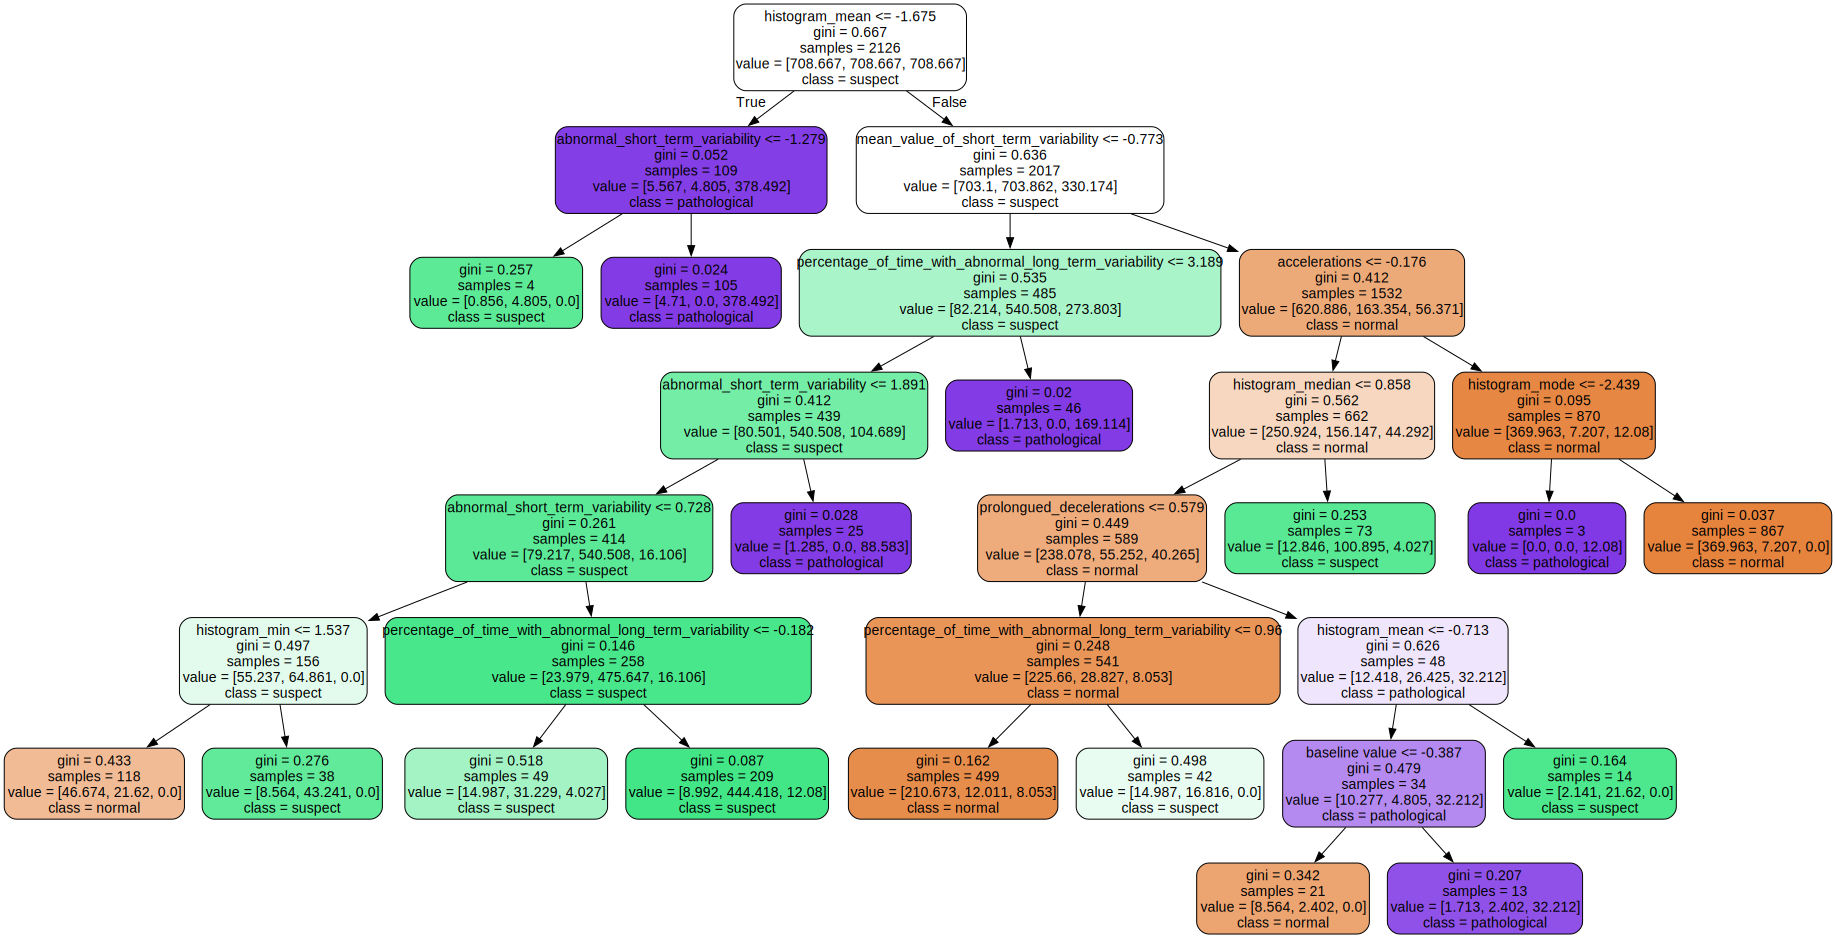

In [42]:
feature_names = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 
                 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 
                 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 
                 'percentage_of_time_with_abnormal_long_term_variability', 
                 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 
                 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 
                 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 
                 'histogram_tendency'] #the column names 

clf = dt_prod_model.best_estimator_.named_steps['estimator'] #this is my final model

dot_data = export_graphviz( #creating the tree
    clf,
    feature_names=feature_names,
    class_names=['normal', 'suspect', 'pathological'],
    filled=True,
    rounded=True,
    out_file=None
)

graph = graphviz.Source(dot_data)
graph

The features that are used in the decision tree are:
- histogram_mean
- abnormal_short_term_variability
- mean_value_of_short_term_variability
- percentage_of_time_with_abnormal_long_term_variability
- accelerations
- histogram_median
- histogram_mode
- prolongued_decelerations
- baseline_value

I can also plot the confusion matrix. This is not a valid evaluation metric since it includes the data the model was trained on. It still gives a good overview over how the model classifies. On the y-axis are the true labels and on the x-axis the predicted labels.

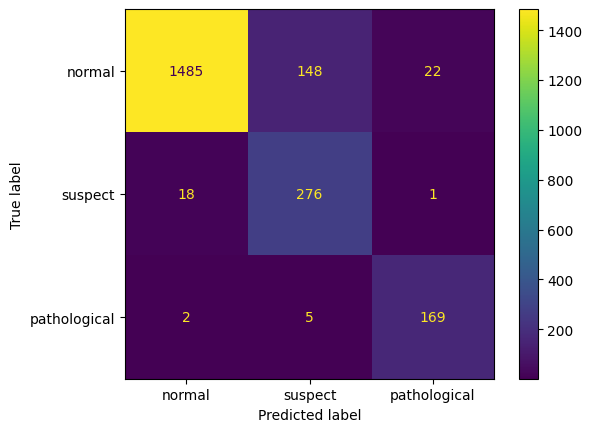

In [43]:
y_pred = dt_prod_model.predict(X) #predicting the class labels
cm = confusion_matrix(y, y_pred) #comparing true labels (y) to the predicted labels (y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'suspect', 'pathological'])
disp.plot();

- most normal cases are correctly classified as normal but still a fair amount of false alarms (suspect and pathological)
- most suspect cases are correctly classified as suspect but some cases are are incorrectly classified as normal  (problematic)
- most pathological cases are correctly classified as pathological but a small amount of cases are incorrectly classified as suspect (not good) or normal (extremely problematic)

## Task 7 - Feature Importance/ Feature Ablation Study

Lastly, I will check which features impact the final model the most and check if the performance improves when I drop features with the lowest importance. Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model's statistical performance. 

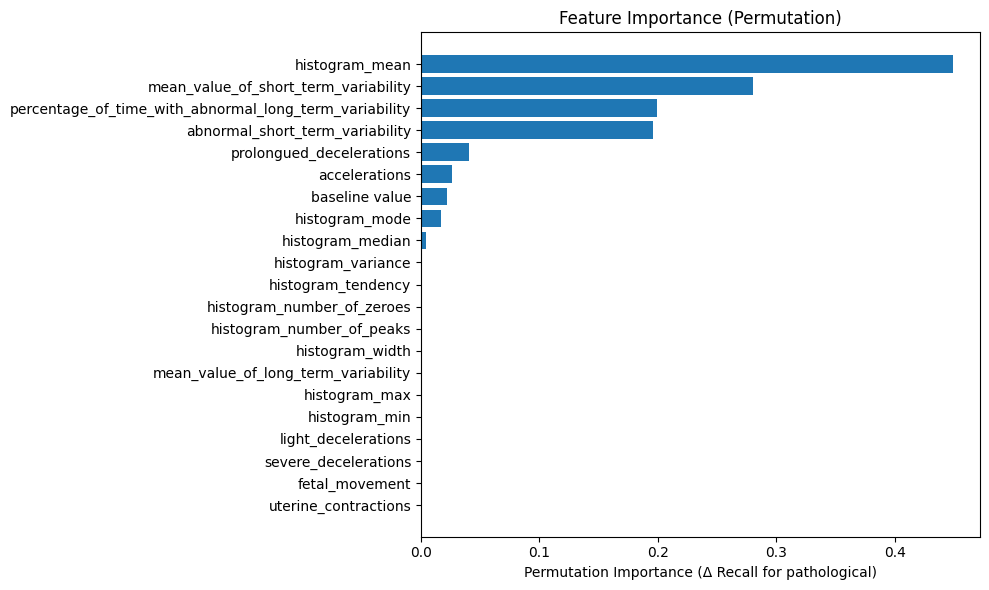

In [ ]:
result = permutation_importance(dt_prod_model.best_estimator_, X, y, scoring=scorer_recall_pathological, n_repeats=10, random_state=1)
#permutation_importance is a sk learn function 

importances = result.importances_mean.flatten() #storing the means of the recall differences across the 10 repeats
sorted_idx = np.argsort(importances)[::-1] #sorting the importances

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[sorted_idx]) #bar chart
plt.yticks(range(len(importances)), np.array(feature_names)[sorted_idx]) #feature names on the y axis
plt.xlabel("Permutation Importance (Δ Recall for pathological)")
plt.title("Feature Importance (Permutation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


On the x-axis you can see the difference in the recall for the pathological class when values of the specific feature are permutated. A high value means that the model uses this feature to a high degree to correctly classify pathological cases. It seems that the heart rate histogram mean and the information about the heart rate flunctuations ('variability') are especially important. All features not included in the decision tree have no impact.

I check for the two least important features:

In [45]:
least_important_idx = sorted_idx[-2:] #the last two items of the sorted array
F1 = feature_names[least_important_idx[0]] #storing the second-least important feature name as F1
F2 = feature_names[least_important_idx[1]] #storing the least important feature name as F2
print("Least important features:", F1, "and", F2) #printing the feature names

Least important features: fetal_movement and uterine_contractions


But, as multiple features have a permutation importance of 0, those are just the two that come last in the array. 

Now, I perform non-nested cross validations of the models without those two features. For that, I write a function that takes the features to drop as an input and then returns the results. And another function to aggregate the results. To include the feature dropping into my pipeline, I use the 'ColumnTranformer' from sklearn which allows to transform specified columns. The way I wrote it, the pipeline only scales the columns which stay in the model and drops the columns specified in the function call.

In [ ]:
final_params = { #the best parameters for my model -> I have to specify them again because dt_prod_model.best_estimator_ contains the pipeline
    'ccp_alpha': 0.0,
    'class_weight': 'balanced',
    'criterion': 'gini',
    'max_depth': 7,
    'max_leaf_nodes': 16,
    'min_samples_leaf': 1,
    'min_samples_split': 2
}

def evaluate_ablation(X, y, features_to_drop, NUM_TRIALS):
    #creating arrays to store the results in 
    bal_acc = []
    recall_pathological = []
    recall_suspect = []
    recall_normal = []
    
    for i in range(NUM_TRIALS): #iterating through the number of trials
        outer_cv = StratifiedKFold( #defining the non-nested cv
            n_splits=NUM_OUTER_SPLITS, shuffle=True, random_state=i)

        features_to_scale = [feature_names.index(f) for f in feature_names if f not in features_to_drop]
        #-> defining the features not to be dropped in the pipeline
        preprocessor = ColumnTransformer( #creating a 'preprocessor' to be included in the new pipeline
            transformers=[
                ('scaler', StandardScaler(), features_to_scale) #scaling only the features not to be dropped
            ],
            remainder='drop' #dropping the features specified in the function call
        )
        pipeline = Pipeline([
            ("preprocessor", preprocessor), #the preprocessor includes dropping the features and scaling the rest
            ("clf", DecisionTreeClassifier(**final_params)) #using the decision tree with the ideal parameters
        ])
        
        scores = cross_validate(#performing the cv
            pipeline, X, y, cv=outer_cv,
            scoring=scoring_metrics, return_train_score=False
        )
        
        #appending the results to the arrays
        bal_acc.append(scores["test_bal_acc"])
        recall_pathological.append(scores["test_recall_pathological"])
        recall_suspect.append(scores["test_recall_suspect"])
        recall_normal.append(scores["test_recall_normal"])
    
    #taking the lists of arrays (from the different trials) and turning them into one array
    bal_acc = np.concatenate(bal_acc)
    recall_pathological = np.concatenate(recall_pathological)
    recall_suspect = np.concatenate(recall_suspect)
    recall_normal = np.concatenate(recall_normal)
    
    #returning a dictionary with the results
    return {
        "bal_acc": bal_acc,
        "recall_pathological": recall_pathological,
        "recall_suspect": recall_suspect,
        "recall_normal": recall_normal
    }

#defining a function that calculates the mean and standard deviation of the metrics
def print_ablation_results(name, scores):
    print(f"{name}:")
    print(f"  Mean Balanced Accuracy: {np.mean(scores['bal_acc']):.4f} ± {np.std(scores['bal_acc']):.4f}")
    print(f"  Mean Recall (pathological): {np.mean(scores['recall_pathological']):.4f} ± {np.std(scores['recall_pathological']):.4f}")
    print(f"  Mean Recall (suspect): {np.mean(scores['recall_suspect']):.4f} ± {np.std(scores['recall_suspect']):.4f}")
    print(f"  Mean Recall (normal): {np.mean(scores['recall_normal']):.4f} ± {np.std(scores['recall_normal']):.4f}")

Now, I use the functions to calculate and print the results for the following scenarios:
- the full model
- the model without fetal movement
- the model without uterine contractions
- the model without fetal movement and uterine contractions

In [ ]:
#same number of trials as defined in task 6 -> 5 trials
scores_full = evaluate_ablation(X, y, [], NUM_TRIALS) #no features to drop -> full model
scores_f1 = evaluate_ablation(X, y, [F1], NUM_TRIALS) #dropping F1 (second-least important feature) -> fetal movement
scores_f2 = evaluate_ablation(X, y, [F2], NUM_TRIALS) #dropping F2 (least important feature) -> uterine contractions
scores_f1f2 = evaluate_ablation(X, y, [F1, F2], NUM_TRIALS) #dropping the two least important features -> fetan movement and uterine contractions

print_ablation_results("Full model", scores_full)
print_ablation_results(f"Drop {F1}", scores_f1)
print_ablation_results(f"Drop {F2}", scores_f2)
print_ablation_results(f"Drop {F1} & {F2}", scores_f1f2)

Full model:
  Mean Balanced Accuracy: 0.9061 ± 0.0235
  Mean Recall (pathological): 0.9522 ± 0.0584
  Mean Recall (suspect): 0.8819 ± 0.0612
  Mean Recall (normal): 0.8841 ± 0.0267
Drop fetal_movement:
  Mean Balanced Accuracy: 0.9056 ± 0.0240
  Mean Recall (pathological): 0.9510 ± 0.0580
  Mean Recall (suspect): 0.8812 ± 0.0619
  Mean Recall (normal): 0.8846 ± 0.0264
Drop uterine_contractions:
  Mean Balanced Accuracy: 0.9062 ± 0.0232
  Mean Recall (pathological): 0.9511 ± 0.0580
  Mean Recall (suspect): 0.8833 ± 0.0611
  Mean Recall (normal): 0.8843 ± 0.0274
Drop fetal_movement & uterine_contractions:
  Mean Balanced Accuracy: 0.9057 ± 0.0236
  Mean Recall (pathological): 0.9499 ± 0.0576
  Mean Recall (suspect): 0.8826 ± 0.0618
  Mean Recall (normal): 0.8845 ± 0.0272


The changes in the performance when dropping the two features is very minor and therefore negligible. Dropping the features neither worsened nor improved the performance. This underlies the fact that fetal movement and uterine contractions are not included in the decision tree and therefore contributing very little to the model. They can be dropped if the goal is a simpler model.

## Task 8 - Conclusions and Future Work

### Achieved results

- Decision Tree and K Nearest Neighbors both work as classifier algorithms that achieve much better results than the baseline
- Decision Tree outperformed KNN in both the default paramatrization and in the nested cross-validation
- Using a nested cross validation to tune the hyperparameters improved the performance and reduced overfitting for the Decision Tree algorithm
- Decision Tree achieved good results in the nested cross validation with a recall of about 95% for pathological cases, a recall of about 89% and a balanced accuracy of about 90%. The recall for the healthy fetuses was lower (87%) but still good. Avoiding false negatives (classifying pathological/suspect fetuses as healthy) was more important than avoiding false positives (classifying healthy fetuses as pathological/suspect)
- The model can be simplified by dropping features without losing performance because many features are not included in the decision tree

### Generated value

- My experiments demonstrate that machine learning can effectively classify fetal health conditions based on CTG data
- The trained model achieved high recall especially for pathological cases, showing potential to assist in the detection of high-risk pregnancies -> **however, this might still not be sufficient in a clinical setting where missing a pathological case is dangerous for both the baby and the mother**
- The model does not make medical judgment obsolete but can provide helpful support to clinicians during the decision making allowing higher efficiency and resource priotization
- The model can serve as a traning tool for less experienced staff

### Ideas for future work

- I have not included all possible parameters in the grid for the Decision Tree because the nested cross validation already took a long time to calculate. But maybe including other parameters (like 'splitter' or 'max_features') would have improved the model
- For the class_weights parameter for the Decision Tree, it would have been possible to try out custom weights (as opposed to balanced or equal weights). There might exist a combination of weights that performs even better than balanced weights
- I have only tried out two algorithms (as asked in the task) and the choice of algorithms had no reason other than personal preference. Another algorithm (e.g. RandomForest, SVM, ...) might have worked better
- The ablation study could be expanded to investigate the impact of dropping features that were actually utilized within the final Decision Tree structure. Dropping the two "least important" features as asked in the task was just dropping two features (among others) that had a permutation importance of 0 and came last in the feature importance array

### Usability of the applied methodology

The goals were realistic and appropriate for the machine learning project. The direct impact on patient safety, patient satisfaction, efficiency/resource prioritization etc. is hard to prove but the experiment demostrated the potential for these.

**strengths**
- The use of Nested Cross-Validation ensured a robust search for optimal hyperparameters, providing a reliable estimate of the model's generalization performance on unseen data
- The selection of balanced accuracy and class-specific recall (especially for pathological cases) addresses the need to correctly identify high-risk instances
- The choice of a Decision Tree enables model understanding and interpretability which is a significant advantage in clinical settings

**limitations/pitfalls**
- The model's generalizability might be limited to the specific data source (e.g., a single clinic, specific equipment, or patient population) it was trained on, potentially reducing its reliability in diverse clinical settings 
- I used existing CTG features which might not fully capture all the nuanced information present in the raw CTG signals
- While I used an iterative grid search to find the best settings for my model, I could only test a specific set of values for each parameter. This means it's still possible that the best settings or other equally good combinations of settings exist outside the ranges I actually explored